Cell 1: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Define repo + Drive paths

In [ ]:
from pathlib import Path

GITHUB_USERNAME = "YOUR_GITHUB_USERNAME"
REPO_NAME = "isro-exoplanet-hackathon-2026"

REPO_PATH = Path(f"/content/{REPO_NAME}")

DRIVE_ROOT = Path("/content/drive/MyDrive/exoplanet_hackathon")
RAW_DIR = DRIVE_ROOT / "data" / "raw_lightcurves"
FIG_DIR = DRIVE_ROOT / "outputs" / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO_PATH)
print("Raw dir:", RAW_DIR)
print("Figure dir:", FIG_DIR)

Repo: /content/isro-exoplanet-hackathon-2026
Raw dir: /content/drive/MyDrive/exoplanet_hackathon/data/raw_lightcurves
Figure dir: /content/drive/MyDrive/exoplanet_hackathon/outputs/figures


Cell 3: Install / import packages

In [ ]:
!pip -q install lightkurve astropy pandas numpy matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 89.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("Imports successful.")

Imports successful.


Cell 4: Set target

In [ ]:
TARGET = "TIC 261136679"
print("Target:", TARGET)

Target: TIC 261136679


Search MAST for available TESS light curves

Cell 5: Search

In [ ]:
search_result = lk.search_lightcurve(
    TARGET,
    mission="TESS",
    author="SPOC"
)

print(search_result)

SearchResult containing 42 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   261136679      0.0
  1 TESS Sector 04 2018   SPOC     120   261136679      0.0
  2 TESS Sector 08 2019   SPOC     120   261136679      0.0
  3 TESS Sector 11 2019   SPOC     120   261136679      0.0
  4 TESS Sector 12 2019   SPOC     120   261136679      0.0
  5 TESS Sector 13 2019   SPOC     120   261136679      0.0
  6 TESS Sector 27 2020   SPOC      20   261136679      0.0
  7 TESS Sector 28 2020   SPOC      20   261136679      0.0
  8 TESS Sector 31 2020   SPOC      20   261136679      0.0
  9 TESS Sector 27 2020   SPOC     120   261136679      0.0
 10 TESS Sector 28 2020   SPOC     120   261136679      0.0
 11 TESS Sector 31 2020   SPOC     120   261136679      0.0
 12 TESS Sector 34 2021   SPOC      20   261136679      0

Cell 6: Download first entry

In [ ]:
if len(search_result) == 0:
    raise ValueError(f"No light curves found for {TARGET}")

lc = search_result[0].download()
print(lc)

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2969604950604  1.4641956e+06 ...  9.0913408e-02 -7.2966635e-02
1325.2983493645327  1.4643365e+06 ...  6.2022530e-02 -1.0871942e-01
 1325.299738234005  1.4643485e+06 ...  6.1673984e-02 -1.1394957e-01
 1325.301127103477  1.4643674e+06 ...  6.0909923e-02 -1.2573890e-01
1325.3025159730657  1.4642560e+06 ...  5.3837594e-02 -1.2532526e-01
 1325.303904842538  1.4644681e+06 ...  5.2977830e-02 -1.2562653e-01
1325.3052937121265  1.4643586e+06 ...  5.7222184e-02 -1.3051888e-01
1325.3066825815986  1.4643564e+06 ...  5.5443291e-02 -1.2712292e-01
1325.3080714511873  1.4645452e+06 ...  5.1877767e-02 -1.2947108e-01
               ...            ... ...            ...            ...
1353.1645661947705  1.4646795e+06 ...  5.5579260e-02 -1.1038263e-02
1353.1659550506233  1.4649392e+06 ...  6.0031198

Cell 7: Basic inspection

In [ ]:
print(type(lc))
print("Available columns:")
print(lc.columns)

<class 'lightkurve.lightcurve.TessLightCurve'>
Available columns:
<TableColumns names=('time','flux','flux_err','timecorr','cadenceno','centroid_col','centroid_row','sap_flux','sap_flux_err','sap_bkg','sap_bkg_err','pdcsap_flux','pdcsap_flux_err','quality','psf_centr1','psf_centr1_err','psf_centr2','psf_centr2_err','mom_centr1','mom_centr1_err','mom_centr2','mom_centr2_err','pos_corr1','pos_corr2')>


Cell 8: Raw plot

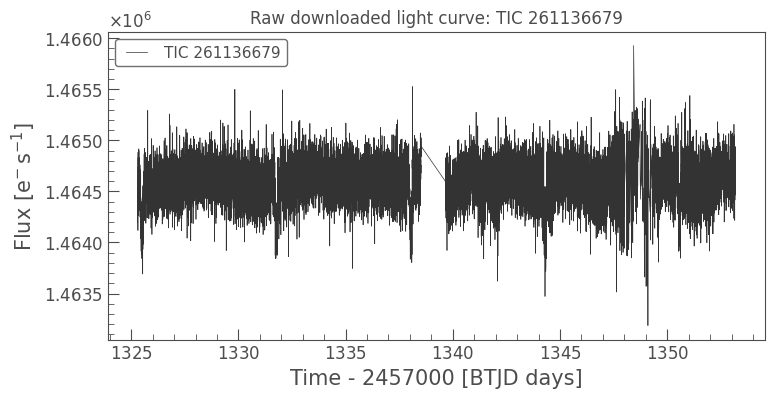

In [ ]:
ax = lc.plot()
ax.set_title(f"Raw downloaded light curve: {TARGET}")
plt.show()

Cell 9: Extract arrays

In [ ]:
time = lc.time.value

# Lightkurve SPOC objects generally expose the cleaned flux as lc.flux
flux = lc.flux.value

mask = np.isfinite(time) & np.isfinite(flux)

time = time[mask]
flux = flux[mask]

print("Valid points:", len(time))
print("Time range:", time.min(), "to", time.max())
print("Flux median:", np.nanmedian(flux))
print("Flux min/max:", np.nanmin(flux), np.nanmax(flux))

Valid points: 18264
Time range: 1325.2969604950604 to 1353.1770658972157
Flux median: 1464602.2
Flux min/max: 1463186.4 1465927.6


Cell 10: Normalize

In [ ]:
flux_norm = flux / np.nanmedian(flux)

print("Normalized flux stats:")
print("min:", np.nanmin(flux_norm))
print("max:", np.nanmax(flux_norm))

Normalized flux stats:
min: 0.9990333
max: 1.0009049


Cell 11: Normalized plot

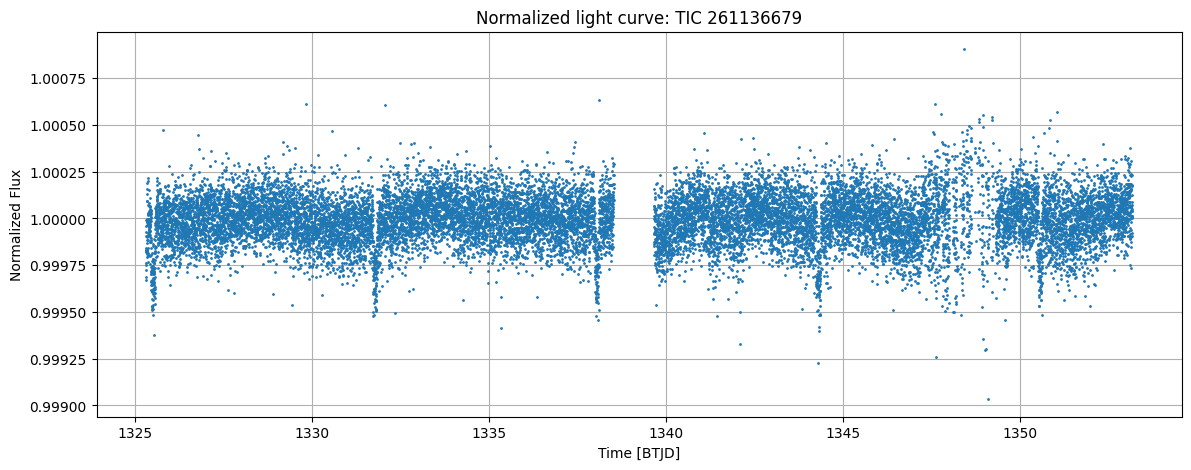

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(time, flux_norm, ".", ms=2)
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized Flux")
plt.title(f"Normalized light curve: {TARGET}")
plt.show()

Cell 12: Save CSV

In [ ]:
df = pd.DataFrame({
    "time": time,
    "flux": flux,
    "flux_norm": flux_norm
})

csv_path = RAW_DIR / "tic_261136679_sector_first.csv"
df.to_csv(csv_path, index=False)

print("Saved CSV to:", csv_path)
print(df.head())

Saved CSV to: /content/drive/MyDrive/exoplanet_hackathon/data/raw_lightcurves/tic_261136679_sector_first.csv
          time         flux  flux_norm
0  1325.296960  1464195.625   0.999722
1  1325.298349  1464336.500   0.999819
2  1325.299738  1464348.500   0.999827
3  1325.301127  1464367.375   0.999840
4  1325.302516  1464256.000   0.999764


Cell 13: Save PNG

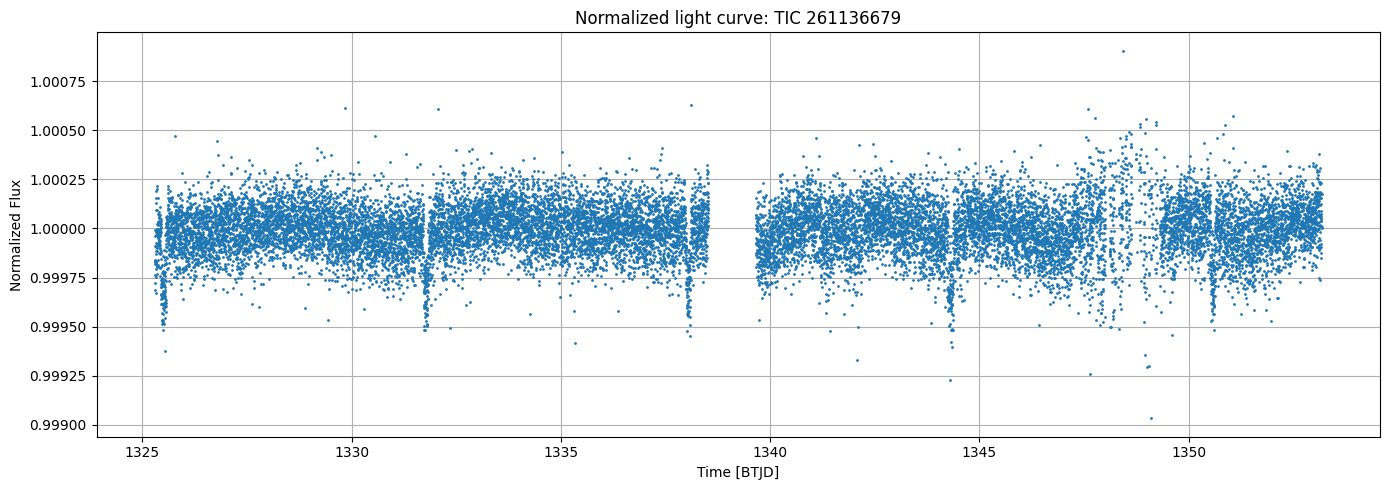

Saved figure to: /content/drive/MyDrive/exoplanet_hackathon/outputs/figures/tic_261136679_normalized.png


In [ ]:
fig_path = FIG_DIR / "tic_261136679_normalized.png"

plt.figure(figsize=(14,5))
plt.plot(time, flux_norm, ".", ms=2)
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized Flux")
plt.title(f"Normalized light curve: {TARGET}")
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)

Cell 14: Show search table as dataframe

In [ ]:
search_df = search_result.table.to_pandas()
search_df.head(20)

,intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,...,size,parent_obsid,dataRights_products,calib_level_products,filters_products,author,mission,#,year,sort_order
0,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2018206045859-s0001-0000000261136679-0120-s,...,2039040,60835895,PUBLIC,3,TESS,SPOC,TESS Sector 01,0,2018,1
1,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2018292075959-s0004-0000000261136679-0124-s,...,1897920,61114378,PUBLIC,3,TESS,SPOC,TESS Sector 04,1,2018,1
2,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2019032160000-s0008-0000000261136679-0136-s,...,1805760,62459906,PUBLIC,3,TESS,SPOC,TESS Sector 08,2,2019,1
3,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2019112060037-s0011-0000000261136679-0143-s,...,1984320,65142109,PUBLIC,3,TESS,SPOC,TESS Sector 11,3,2019,1
4,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2019140104343-s0012-0000000261136679-0144-s,...,2041920,65182732,PUBLIC,3,TESS,SPOC,TESS Sector 12,4,2019,1
5,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2019169103026-s0013-0000000261136679-0146-s,...,2079360,65462812,PUBLIC,3,TESS,SPOC,TESS Sector 13,5,2019,1
6,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2020186164531-s0027-0000000261136679-0189-...,...,10558080,27811411,PUBLIC,3,TESS,SPOC,TESS Sector 27,6,2020,1
7,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2020212050318-s0028-0000000261136679-0190-...,...,10941120,27823276,PUBLIC,3,TESS,SPOC,TESS Sector 28,7,2020,1
8,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2020294194027-s0031-0000000261136679-0198-...,...,11018880,28062277,PUBLIC,3,TESS,SPOC,TESS Sector 31,8,2020,1
9,science,TESS,SPOC,Photometer,TESS,TESS,Optical,261136679,NaN,tess2020186164531-s0027-0000000261136679-0189-s,...,1785600,27803712,PUBLIC,3,TESS,SPOC,TESS Sector 27,9,2020,1
